# 05 Compare Baseline vs PINN

Confronta RMSE posizione per corpo e per finestra temporale tra modello baseline e variante PINN.


In [1]:
from pathlib import Path
import sys

_cwd = Path.cwd().resolve()
_candidates = [_cwd, _cwd / 'PINN', _cwd.parent, _cwd.parent / 'PINN', _cwd.parent.parent]
_PROJECT_ROOT = next((p for p in _candidates if (p / 'src' / 'solsys_emulator').exists()), None)
if _PROJECT_ROOT is None:
    raise RuntimeError('Impossibile trovare la project root con src/solsys_emulator')

_SRC = _PROJECT_ROOT / 'src'
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

print('Project root:', _PROJECT_ROOT)
print('Python executable:', sys.executable)


Project root: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/PINN
Python executable: /Applications/Xcode.app/Contents/Developer/usr/bin/python3


MLP train_time_range_seconds: {'min': 315576000.0, 'max': 946728000.0}
PINN train_time_range_seconds: {'min': 315576000.0, 'max': 946728000.0}


/Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/PINN/src/solsys_emulator/inference.py:154: RuntimeWarning: Inference requested outside training interval [2010-01-01T00:00:00.000, 2030-01-01T00:00:00.000] (TDB); extrapolation errors may be very large.
  states = self._predict_raw(time_grid)


MLP (progetto principale) ckpt: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/artifacts/emulator_demo.pt
PINN ckpt: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/PINN/artifacts/emulator_pinn.pt

[interp_2025]
  baseline mean RMSE [km]: 218,229.80 | median: 96,648.49 | max: 570,555.49
  PINN     mean RMSE [km]: 270,776.21 | median: 124,368.15 | max: 626,413.65

[interp_2029]
  baseline mean RMSE [km]: 232,331.07 | median: 115,813.80 | max: 576,480.72
  PINN     mean RMSE [km]: 296,439.38 | median: 145,640.08 | max: 619,459.10

[extra_2030]
  baseline mean RMSE [km]: 539,302,100.63 | median: 187,409,250.12 | max: 1,399,901,329.80
  PINN     mean RMSE [km]: 512,626,668.29 | median: 167,273,104.05 | max: 1,289,861,382.22


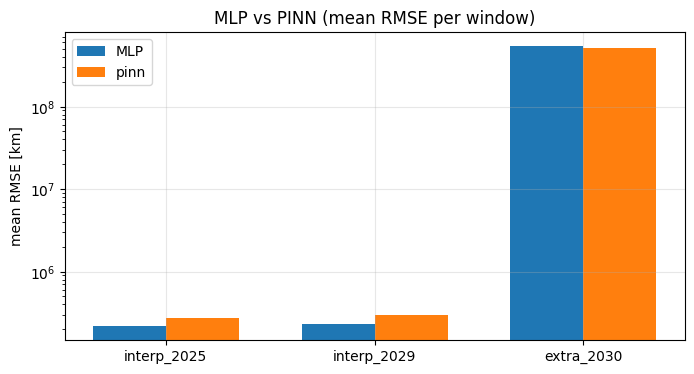

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from solsys_emulator.config import DEFAULT_KERNEL_PATH
from solsys_emulator.de440_dataset import find_local_kernel, load_kernel, sample_states
from solsys_emulator.inference import EphemerisEmulator
from solsys_emulator.train import load_checkpoint
from solsys_emulator.time_frames import build_time_grid

pinn_root = _PROJECT_ROOT
baseline_ckpt = pinn_root.parent / 'artifacts' / 'emulator_demo.pt'
if not baseline_ckpt.exists():
    raise FileNotFoundError('Checkpoint MLP del progetto principale non trovato: ../artifacts/emulator_demo.pt')

pinn_ckpt = pinn_root / 'artifacts' / 'emulator_pinn.pt'

if not pinn_ckpt.exists():
    raise FileNotFoundError('PINN checkpoint non trovato. Esegui prima 02_train_emulator.ipynb in PINN/.')

kernel_path = find_local_kernel([DEFAULT_KERNEL_PATH])
if kernel_path is None:
    raise RuntimeError('Nessun kernel DE440/DE441 trovato in data/.')
kernel = load_kernel(kernel_path)

mlp_meta = load_checkpoint(baseline_ckpt)
pinn_meta = load_checkpoint(pinn_ckpt)
print('MLP model kwargs:', mlp_meta.get('model_kwargs', {}))
print('PINN model kwargs:', pinn_meta.get('model_kwargs', {}))
mlp_time_range = mlp_meta.get('metadata', {}).get('train_time_range_seconds')
pinn_time_range = pinn_meta.get('metadata', {}).get('train_time_range_seconds')
print('MLP train_time_range_seconds:', mlp_time_range)
print('PINN train_time_range_seconds:', pinn_time_range)
if mlp_time_range != pinn_time_range:
    print('WARNING: i due checkpoint potrebbero essere stati addestrati su finestre temporali diverse.')

windows = [
    ('2025-01-01T00:00:00', '2026-01-01T00:00:00', 'interp_2025'),
    ('2029-01-01T00:00:00', '2030-01-01T00:00:00', 'interp_2029'),
    ('2030-01-01T00:00:00', '2031-01-01T00:00:00', 'extra_2030'),
]
dt_seconds = 21600.0

def evaluate_checkpoint(ckpt_path):
    emu = EphemerisEmulator.from_checkpoint(ckpt_path)
    bodies = [b for b in emu.bodies if b.lower() != 'sun']
    results = {}
    for t0, t1, label in windows:
        pred = {b: emu.predict_trajectory(b, t0, t1, dt_seconds) for b in bodies}
        _, tg = build_time_grid(t0, t1, dt_seconds)
        true_states, _ = sample_states(tg, bodies=bodies, kernel=kernel)
        per_body = {}
        for i, b in enumerate(bodies):
            err = pred[b] - true_states[:, i, :3]
            per_body[b] = float(np.sqrt(np.mean(np.sum(err * err, axis=1))))
        arr = np.asarray(list(per_body.values()), dtype=float)
        results[label] = {
            'mean': float(np.mean(arr)),
            'median': float(np.median(arr)),
            'max': float(np.max(arr)),
            'per_body': per_body,
        }
    return results

baseline_res = evaluate_checkpoint(baseline_ckpt)
pinn_res = evaluate_checkpoint(pinn_ckpt)

print('MLP (progetto principale) ckpt:', baseline_ckpt)
print('PINN ckpt:', pinn_ckpt)

for _, _, label in windows:
    b = baseline_res[label]
    p = pinn_res[label]
    print(f'\n[{label}]')
    print(f"  baseline mean RMSE [km]: {b['mean']:,.2f} | median: {b['median']:,.2f} | max: {b['max']:,.2f}")
    print(f"  PINN     mean RMSE [km]: {p['mean']:,.2f} | median: {p['median']:,.2f} | max: {p['max']:,.2f}")

labels = [label for _, _, label in windows]
baseline_means = [baseline_res[l]['mean'] for l in labels]
pinn_means = [pinn_res[l]['mean'] for l in labels]
x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - w/2, baseline_means, width=w, label='MLP')
plt.bar(x + w/2, pinn_means, width=w, label='pinn')
plt.yscale('log')
plt.xticks(x, labels)
plt.ylabel('mean RMSE [km]')
plt.title('MLP vs PINN (mean RMSE per window)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

